<h1> Thompson Sampling

Conceptually, this is the most interesting part of Bandit, as it connects directly to what we did in Section 07:
Bayesian Reasoning

#### ε-Greedy

Decision-Making:
Random Exploration
+
Greedy Exploitation

#### UCB

Decision-Making:
Estimated Value
+
Uncertainty Bonus

#### Thompson Sampling

Decision-Making:
Instead of keeping a fixed value for the value of each Action, we keep a probability distribution for it.

The philosophical difference between the three methods:</br>
Epsilon-Greedy:</br>
It says:</br>
Sometimes, try things blindly.

UCB:</br>
It says:</br>
Try what might be the best.

Thompson Sampling:</br>
It says:</br>
Sample based on my probabilistic belief.

An important difference:

Our previous environment used:</br>
np.random.normal()

This means the reward is:</br>
Continuous

The Thompson Sampling method above is for:</br>
Binary rewards

So, for this notebook, we will create a new environment:</br>
Bernoulli Bandit Environment

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from src.bandit import (
    BernoulliBandit,
    ThompsonSamplingAgent
)

<h3> Step 1: Bernoulli Bandit Environment

In [17]:
def run_agent(
    bandit,
    agent,
    steps=1000
):
    rewards = []
    actions = []

    for _ in range(steps):
        action = agent.select_action()
        reward = bandit.step(action)
        agent.update(
            action,
            reward
        )

        rewards.append(reward)
        actions.append(action)

    return rewards, actions

In [18]:
bandit = BernoulliBandit(
    [
        0.2,
        0.5,
        0.8
    ]
)

In [19]:
agent = ThompsonSamplingAgent(
    n_arms=3
)

In [20]:
rewards, actions = run_agent(
    bandit,
    agent,
    steps=5000
)

<h3> 1. Learning Curve Analysis — Average Reward

Since the environment is a Bernoulli bandit this time, the criteria are slightly different.

In [21]:
ts_avg_reward = (
    np.cumsum(rewards)
    /
    np.arange(
        1,
        len(rewards)+1
    )
)

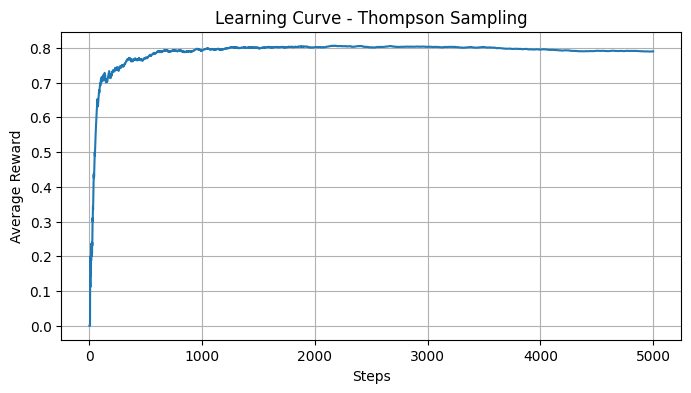

In [22]:
plt.figure(figsize=(8,4))

plt.plot(
    ts_avg_reward
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Average Reward"
)

plt.title(
    "Learning Curve - Thompson Sampling"
)

plt.grid()
plt.show()

#### Learning Curve Analysis - Thompson Sampling

The Thompson Sampling agent quickly improves its performance by updating the posterior distribution of each arm after observing rewards.

The average reward rapidly increases during the early exploration phase and converges close to the optimal arm probability.

This shows that Bayesian sampling provides an efficient balance between exploration and exploitation.

<h3> 2. Cumulative Regret

Since our environment is Bernoulli, we have the probability for each arm.

In [23]:
bandit.probabilities

[0.2, 0.5, 0.8]

Best possibility:

In [24]:
best_probability = max(
    bandit.probabilities
)

best_probability

0.8

Selected Probability:

In [25]:
chosen_probabilities = np.array([
    bandit.probabilities[a]
    for a in actions
])

chosen_probabilities

array([0.5, 0.5, 0.8, ..., 0.8, 0.8, 0.8])

Regret:

In [26]:
ts_regret = (
    best_probability
    -
    chosen_probabilities
)

ts_regret

array([0.3, 0.3, 0. , ..., 0. , 0. , 0. ])

Cumulative:

In [27]:
ts_cumulative_regret = np.cumsum(
    ts_regret
)

ts_cumulative_regret

array([ 0.3,  0.6,  0.6, ..., 10.8, 10.8, 10.8])

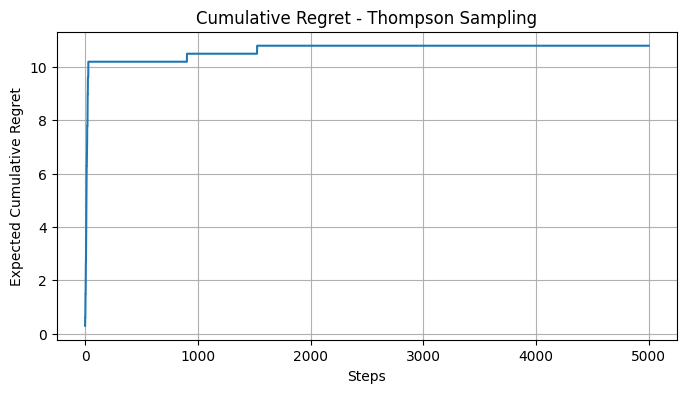

In [28]:
plt.figure(figsize=(8,4))

plt.plot(
    ts_cumulative_regret
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Expected Cumulative Regret"
)

plt.title(
    "Cumulative Regret - Thompson Sampling"
)

plt.grid()
plt.show()

#### Cumulative Regret Analysis - Thompson Sampling

The cumulative regret increases mainly during the initial exploration phase.

After enough observations, the posterior distributions become concentrated around the true probabilities, allowing the agent to select the optimal arm consistently.

The nearly flat regret curve indicates efficient learning with minimal unnecessary exploration.

<h3> 3. Visualization

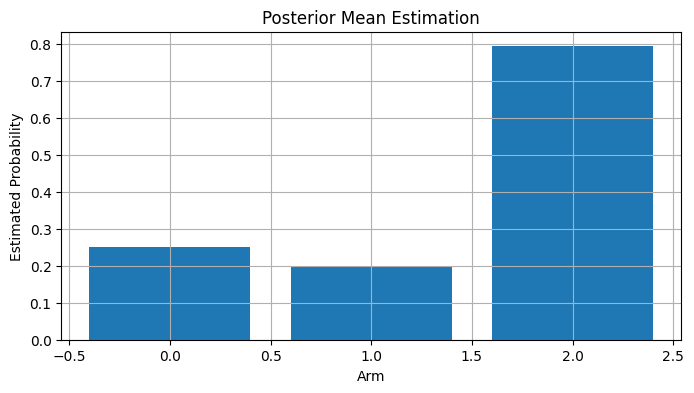

In [30]:
plt.figure(figsize=(8,4))

plt.bar(
    range(agent.n_arms),
    agent.alpha /
    (agent.alpha + agent.beta)
)

plt.xlabel(
    "Arm"
)

plt.ylabel(
    "Estimated Probability"
)

plt.title(
    "Posterior Mean Estimation"
)

plt.grid()
plt.show()

#### Posterior Estimation Analysis

Thompson Sampling maintains a probability distribution over the expected reward of each arm.

The posterior mean estimation shows that the agent successfully learned the underlying reward probabilities.

The optimal arm received significantly more observations, resulting in a more accurate posterior estimation compared to less explored arms.

<h3> 4. Examination of Posterior Parameters

This part is the most important section of Thompson.

In [ ]:
print("Alpha:")
print(agent.alpha)

print("\nBeta:")
print(agent.beta)

Alpha:
[4.000e+00 2.000e+00 3.946e+03]

Beta:
[  12.    8. 1034.]


<h3> 5. Examine Best Arm

In [ ]:
estimated_probabilities = (
    agent.alpha /
    (agent.alpha + agent.beta)
)

print(
    "True best arm:",
    np.argmax(
        bandit.probabilities
    )
)

print(
    "Agent best arm:",
    np.argmax(
        estimated_probabilities
    )
)

True best arm: 2
Agent best arm: 2


#### Thompson Sampling Final Analysis

Thompson Sampling successfully learned the optimal arm by maintaining Bayesian posterior distributions for each action.

The agent updated the Beta distributions using observed successes and failures, gradually increasing confidence in better-performing arms.

The posterior estimation correctly identified the optimal arm, and the cumulative regret remained low after the initial exploration phase.

This demonstrates the advantage of Bayesian decision-making: exploration is naturally guided by uncertainty without requiring manually tuned exploration parameters.